In [5]:
import adlfs

# Get this from: Storage Account → Security + networking → Access keys
fs = adlfs.AzureBlobFileSystem(
    account_name="triagestorage123",
    account_key="YOUR_ACCOUNT_KEY",
)

fs.ls("gold/")

['gold/features']

In [4]:
df = pd.read_parquet(
    "abfs://gold/features",
    storage_options={
        "account_name": "triagestorage123",
        "account_key": "YOUR_ACCOUNT_KEY",
    }
)
df.head()

,patient_id,chief_complaint_raw,chief_complaint_system,age,sex,heart_rate,respiratory_rate,temperature_c,spo2,triage_acuity,has_abnormalheartrate,has_hightemp,has_lowspo2,has_lowrespiration
0,TG-UXRGA9UCO,45,neurological,43,M,57,17.0,37.0,92,2,0,0,1,0
1,TG-B19DBBS2G,34,genitourinary,72,F,97,17.0,36.9,99,5,0,0,0,0
2,TG-GZ97W7M6V,37,other,82,M,75,14.0,37.3,100,5,0,0,0,0
3,TG-THIB2TN9Q,40,dermatological,50,F,109,17.0,38.2,96,3,1,1,0,0
4,TG-J3U3LQ2QY,34,dermatological,62,M,113,17.0,36.6,99,3,1,0,0,0


In [9]:
import sys
!{sys.executable} -m pip install nltk


  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.6/793.6 kB 22.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [nltk]1/2 [nltk]


In [16]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

df['chief_complaint_tokens'] = df['chief_complaint_raw'].astype(str).apply(word_tokenize)
df[['chief_complaint_raw', 'chief_complaint_tokens']].head()
df.head()

[nltk_data] Downloading package punkt to /home/azureuser/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/azureuser/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,patient_id,chief_complaint_raw,chief_complaint_system,age,sex,heart_rate,respiratory_rate,temperature_c,spo2,triage_acuity,has_abnormalheartrate,has_hightemp,has_lowspo2,has_lowrespiration,chief_complaint_tokens
0,TG-UXRGA9UCO,45,neurological,43,M,57,17.0,37.0,92,2,0,0,1,0,[45]
1,TG-B19DBBS2G,34,genitourinary,72,F,97,17.0,36.9,99,5,0,0,0,0,[34]
2,TG-GZ97W7M6V,37,other,82,M,75,14.0,37.3,100,5,0,0,0,0,[37]
3,TG-THIB2TN9Q,40,dermatological,50,F,109,17.0,38.2,96,3,1,1,0,0,[40]
4,TG-J3U3LQ2QY,34,dermatological,62,M,113,17.0,36.6,99,3,1,0,0,0,[34]


In [19]:
import sys
!{sys.executable} -m pip install scikit-learn

              precision    recall  f1-score   support

           1       0.79      0.48      0.59       644
           2       0.77      0.76      0.77      2688
           3       0.76      0.77      0.77      5784
           4       0.63      0.68      0.65      4604
           5       0.66      0.60      0.63      2280

    accuracy                           0.71     16000
   macro avg       0.72      0.66      0.68     16000
weighted avg       0.71      0.71      0.71     16000



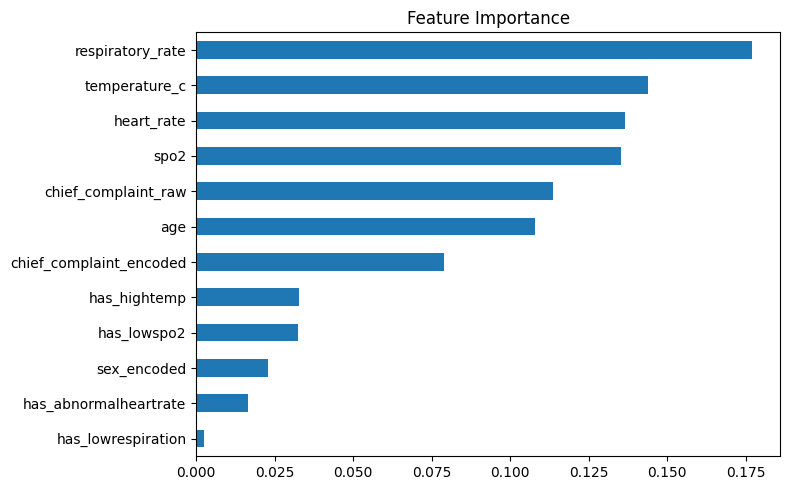

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ── Feature Engineering ──────────────────────────────────────────────
# Encode categorical columns
le_sex = LabelEncoder()
le_cc  = LabelEncoder()

df['sex_encoded'] = le_sex.fit_transform(df['sex'])
df['chief_complaint_encoded'] = le_cc.fit_transform(df['chief_complaint_system'])

# Define features and target
features = [
    'chief_complaint_raw',
    'chief_complaint_encoded',
    'age',
    'sex_encoded',
    'heart_rate',
    'respiratory_rate',
    'temperature_c',
    'spo2',
    'has_abnormalheartrate',
    'has_hightemp',
    'has_lowspo2',
    'has_lowrespiration',
]

X = df[features]
y = df['triage_acuity']

# ── Train/Test Split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Model ────────────────────────────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ── Evaluation ───────────────────────────────────────────────────────
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# ── Feature Importance ───────────────────────────────────────────────
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

importance.plot(kind='barh', figsize=(8, 5), title='Feature Importance')
plt.tight_layout()
plt.show()

In [23]:
import joblib
import io
import adlfs
from azure.identity import ClientSecretCredential

# ── Authenticate ─────────────────────────────────────────────────────
fs = adlfs.AzureBlobFileSystem(
    account_name="triagestorage123",
    account_key="YOUR_ACCOUNT_KEY",  # or use credential= for service principal
)

# ── Serialize model to bytes ──────────────────────────────────────────
buffer = io.BytesIO()
joblib.dump(model, buffer)
buffer.seek(0)

# ── Upload to ADLS ───────────────────────────────────────────────────
with fs.open("gold/models/triage_model_v1.pkl", "wb") as f:
    f.write(buffer.read())

print("Model saved to gold/models/triage_model_v1.pkl")

Model saved to gold/models/triage_model_v1.pkl
